# Example of likelihood calculation for the spectroscopic observables (Full shape)

__Warning__: to run this part of the notebook it is necessary to first install the comet package. To do so, just get the last version (2.0.5) of the code from PyPI with `pip install comet-emu`

__Please note__: in case you already have a previous installation of comet (1.x) in your system (or environment), the installation of this specific version could create some incompatibility issues. Therefore, we recommend to create a fresh new environment and installing this version from scratch. Alternatively, you can uninstall your current version of comet with `pip uninstall comet-emu`, explicitly removing the comet folder from your installation path, and finally installing the new PyPI version.

In this part we make use of the EFT model.

In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.observables.CometEFT_spectro import CometEFT_SpectroPower

# cloelike imports
from cloelike.EuclidLikelihood_GCspectro_Pls import EuclidLikelihood_GCspectro_Pls

Warning! "libgrid.so" not found, bispectrum binning options will not be available.


/Users/pezzotta/miniforge3/envs/cloe-env_3.10/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


### Download the data

In [2]:
# Execute this cell to download the data for testing the likelihood calculations
data_downloaded = False

if data_downloaded == False:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'cov_Gauss_GCspectro_comet_EFT_z1.2_2500deg2.fits': 'https://zenodo.org/records/15543831/files/cov_Gauss_GCspectro_comet_EFT_z1.2_2500deg2.fits',
        'cov_Gauss_GCspectro_comet_EFT_z1.4_2500deg2.fits': 'https://zenodo.org/records/15543831/files/cov_Gauss_GCspectro_comet_EFT_z1.4_2500deg2.fits',
        'cov_Gauss_GCspectro_comet_EFT_z1.65_2500deg2.fits': 'https://zenodo.org/records/15543831/files/cov_Gauss_GCspectro_comet_EFT_z1.65_2500deg2.fits',
        'cov_Gauss_GCspectro_comet_EFT_z1._2500deg2.fits': 'https://zenodo.org/records/15543831/files/cov_Gauss_GCspectro_comet_EFT_z1._2500deg2.fits',
        'mixmat_identity_z1..fits': 'https://zenodo.org/records/15543831/files/mixmat_identity_z1..fits',
        'mixmat_identity_z1.2.fits': 'https://zenodo.org/records/15543831/files/mixmat_identity_z1.2.fits',
        'mixmat_identity_z1.4.fits': 'https://zenodo.org/records/15543831/files/mixmat_identity_z1.4.fits',
        'mixmat_identity_z1.65.fits': 'https://zenodo.org/records/15543831/files/mixmat_identity_z1.65.fits',
    }
    
    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

cov_Gauss_GCspectro_comet_EFT_z1.2_2500deg2.fits downloaded successfully
cov_Gauss_GCspectro_comet_EFT_z1.4_2500deg2.fits downloaded successfully
cov_Gauss_GCspectro_comet_EFT_z1.65_2500deg2.fits downloaded successfully
cov_Gauss_GCspectro_comet_EFT_z1._2500deg2.fits downloaded successfully
mixmat_identity_z1..fits downloaded successfully
mixmat_identity_z1.2.fits downloaded successfully
mixmat_identity_z1.4.fits downloaded successfully
mixmat_identity_z1.65.fits downloaded successfully


### Define redshifts and read data and fiducial cosmology

Soon, the reading of the input data will happen via euclidlib

In [3]:
# Redshifts of the samples (we transform them to strings to have identifiers of the bins)
redshifts = [1.0, 1.2, 1.4, 1.65]
labels = [str(z).strip('0') for z in redshifts]

data = {
    # Data (we fill this part below)
    'GCspectro': {},
    # Fiducial cosmology (required for geometrical (AP) distortions)
    'fiducial_cosmology': {
        'H0': 67.0,
        'Omega_cdm0': 0.27, 'Omega_b0': 0.049, 'Omega_k0': 0.0, 'mnu': 0.0, 'N_mnu': 0,
        'w0': -1.0, 'wa': 0.0,
        'ns': 0.96, 'As': 2.1e-9,
        'gamma_MG': 0.545       
    }
}

# Rescaling of the units (as, at the moment, cloelib works in Mpc units, while the data vectors are stored in Mpc/h units)
fid_h = data['fiducial_cosmology']['H0'] / 100.0
k_fac = fid_h
pk_fac = 1.0 / fid_h**3
cov_fac = 1.0 / fid_h**6

# Number densities
nbar = np.array([2.042611E-03, 1.02876011E-03, 0.58531983E-03, 0.313402E-03]) * fid_h**3

# Here we read the data vectors and covariance matrices and store them into the data dictionary
def get_index(multipole, scale, scale_dict):
    offset = sum(len(scale_dict[ell]) for ell in multipoles if ell < multipole)
    return offset + np.where(scale_dict[multipole] == scale)[0][0]

for ii,z in enumerate(labels):
    # Looping over the identifiers (redshifts)
    data['GCspectro'][z] = {}

    # Storing data vectors
    filename = f'cov_Gauss_GCspectro_comet_EFT_z{z}_2500deg2.fits'
    #filename = f'/Users/pezzotta/work/cloe/data/cov_EFT_z{z}.fits'
    hdul = fits.open(filename)
    average = hdul['AVERAGE'].data
    data['GCspectro'][z]['k'] = average['SCALE_1DIM'] * k_fac
    data['GCspectro'][z]['pk0'] = average['AVERAGE0'] * pk_fac
    data['GCspectro'][z]['pk2'] = average['AVERAGE2'] * pk_fac
    data['GCspectro'][z]['pk4'] = average['AVERAGE4'] * pk_fac

    # Storing covariance matrices
    covariance = hdul['COVARIANCE'].data
    scale_i = covariance["SCALE_1DIM-I"]
    multipole_i = covariance["MULTIPOLE-I"]
    scale_j = covariance["SCALE_1DIM-J"]
    multipole_j = covariance["MULTIPOLE-J"]
    covariance = covariance["COVARIANCE"]

    multipoles = np.array([0, 2, 4])
    scale_dict = {ell: np.unique(scale_i[multipole_i == ell]) for ell in multipoles}
    matrix_size = sum(len(scale_dict[ell]) for ell in multipoles)
    cov_matrix = np.zeros((matrix_size, matrix_size))
    for s_i, m_i, s_j, m_j, cov in zip(scale_i, multipole_i, scale_j, multipole_j, covariance):
        i = get_index(m_i, s_i, scale_dict)
        j = get_index(m_j, s_j, scale_dict)
        cov_matrix[i, j] = cov
    data['GCspectro'][z]['cov'] = cov_matrix * cov_fac

    # Storing number densities
    data['GCspectro'][z]['nbar'] = nbar[ii]

    # Mixing matrices
    root = f'mixmat_identity_z{z}.fits'
    fits_file = fits.open(root)

    kin0 = fits_file['BINS_INPUT'].data['kp0'] * k_fac
    kin2 = fits_file['BINS_INPUT'].data['kp2'] * k_fac
    kin4 = fits_file['BINS_INPUT'].data['kp4'] * k_fac
    kout = fits_file['BINS_OUTPUT'].data['k'] * k_fac
    mixing_matrix = fits_file['MIXING_MATRIX'].data

    mixing_matrix_dict = {}

    mixing_matrix_dict['kout'] = kout
    mixing_matrix_dict['kin0'] = kin0
    mixing_matrix_dict['kin2'] = kin2
    mixing_matrix_dict['kin4'] = kin4
    for i in [0, 2, 4]:
        for j in [0, 2, 4]:
            mm = f'W{i}{j}'
            mixing_matrix_dict[mm] = mixing_matrix[mm]

    data['GCspectro'][z]['mixing_matrix'] = mixing_matrix_dict

### Define scale cuts

In [4]:
settings = {
    'scale_cuts': {
        'GCspectro': {
            'bin1': {'ell0': [0.0, 0.20], 'ell2': [0.0, 0.15], 'ell4': [0.0, 0.15]},
            'bin2': {'ell0': [0.0, 0.25], 'ell2': [0.0, 0.20], 'ell4': [0.0, 0.20]},
            'bin3': {'ell0': [0.0, 0.25], 'ell2': [0.0, 0.20], 'ell4': [0.0, 0.20]},
            'bin4': {'ell0': [0.0, 0.30], 'ell2': [0.0, 0.25], 'ell4': [0.0, 0.25]}
        }
    }
}

# Also in this case we have passed the scale cuts in Mpc/h units, so we need to transform them into Mpc
settings = {
    'scale_cuts': {
        'GCspectro': {
            bin_key: {ell_key: [v * fid_h for v in values] for ell_key, values in bin_values.items()}
            for bin_key, bin_values in settings['scale_cuts']['GCspectro'].items()
        }
    }
}

### Likelihood initialisation

This requires specifying the data and settings dictionaries, plus a type of Background and SpectroPower objects

In [5]:
import time

print("🔍 Timing log-likelihood initialisation for spectroscopic GC:")

start = time.time()

like_spec = EuclidLikelihood_GCspectro_Pls(
    data=data,
    settings=settings,
    Background=CAMBBackground,
    SpectroPower=CometEFT_SpectroPower,
)

end = time.time()

print(f"✅ Spectroscopic GC likelihood initialised.")
print(f"⏱️ Time elapsed: {end - start:.3f} seconds")


🔍 Timing log-likelihood initialisation for spectroscopic GC:
✅ Spectroscopic GC likelihood initialised.
⏱️ Time elapsed: 0.022 seconds


### Likelihood evaluation

In [6]:
parameters = {
    'H0': 67.0,
    'Omega_cdm0': 0.27, 'Omega_b0': 0.049, 'Omega_k0': 0.0, 'mnu': 0.0, 'N_mnu': 0,
    'w0': -1.0, 'wa': 0.0,
    'ns': 0.96, 'As': 2.1e-9,
    'gamma_MG': 0.545,
    'b1': np.array([1.412, 1.769, 2.039, 2.496]),
    'b2': np.array([0.695, 0.870, 1.162, 2.010]),
    'bG2': np.array([-0.156, -0.299, -0.400, -0.555]),
    'bGam3': np.array([0.323, 0.621, 0.827, 1.137]),
    'c0': np.array([30.948, 37.116, 36.738, 53.627]),
    'c2': np.array([46.233, 53.071, 48.626, 60.962]),
    'c4': np.array([10.057, 10.385, 8.643, 8.711]),
    'cnlo': np.array([0.0, 0.0, 0.0, 0.0]),
    'NP0': np.array([1.056, 1.152, 1.144, 1.309]),
    'NP20': np.array([0.0, 0.0, 0.0, 0.0]),
    'NP22': np.array([0.0, 0.0, 0.0, 0.0]),
    'fout': np.array([0.0, 0.0, 0.0, 0.0]),
    'sigmaz': np.array([0.0, 0.0, 0.0, 0.0])
}

print("⏱️ Timing log-likelihood evaluation:")

start = time.time()
loglike_val = like_spec.loglike(parameters)
end = time.time()

print(f"Log-likelihood: {loglike_val}")
print(f"-2 * log-likelihood: {-2 * loglike_val}")
print(f"⏱️ Time elapsed: {end - start:.3f} seconds")

⏱️ Timing log-likelihood evaluation:
Log-likelihood: -0.015885867453973235
-2 * log-likelihood: 0.03177173490794647
⏱️ Time elapsed: 0.371 seconds


We can easily reevaluate the $\chi^2$ changing the parameters

In [7]:
from IPython.display import display, Math

def print_chi2(parameters, like, description):
    chi2 = -2 * like.loglike(parameters)
    print(f"🔧 {description}")
    display(Math(r"\chi^2 = {:.3f}".format(chi2)))
    print("-" * 40)

# Starting from original parameters dict
params = parameters.copy()  # to avoid modifying original dict if needed

# 1. Change H0 to 70.0
params['H0'] = 70.0
print_chi2(params, like_spec, "Changed H0 to 70.0")

# 2. Change H0 back to 67.0, b1 to [2.0, 2.0, 2.0, 2.0]
params['H0'] = 67.0
params['b1'] = np.repeat(2.0, 4)
print_chi2(params, like_spec, "Reset H0 to 67.0 and set b1 = 2.0 (all bins)")

# 3. Change w0 to -1.2
params['w0'] = -1.2
print_chi2(params, like_spec, "Set w0 to -1.2")

# 4. Change Omega_k0 to 0.2
params['Omega_k0'] = 0.2
print_chi2(params, like_spec, "Set Omega_k0 to 0.2")

# 5. Change bGam3 to [0.5, 0.5, 0.5, 0.5]
params['bGam3'] = np.repeat(0.5, 4)
print_chi2(params, like_spec, "Set bGam3 = 0.5 (all bins)")



🔧 Changed H0 to 70.0


<IPython.core.display.Math object>

----------------------------------------
🔧 Reset H0 to 67.0 and set b1 = 2.0 (all bins)


<IPython.core.display.Math object>

----------------------------------------
🔧 Set w0 to -1.2


...

----------------------------------------
🔧 Set Omega_k0 to 0.2


<IPython.core.display.Math object>

----------------------------------------
🔧 Set bGam3 = 0.5 (all bins)


<IPython.core.display.Math object>

----------------------------------------


Let's check them against the built-in Comet $\chi^2$ method

In [8]:
from comet import comet

# Initialize the EFT emulator
emu = comet('EFT', use_Mpc=True, bias_basis='AssBauGre')

# Define number densities, scaled by h^3
nbar = np.array([2.042611E-03, 1.02876011E-03, 0.58531983E-03, 0.313402E-03]) * 0.67**3
emu.define_nbar(nbar=nbar)

# Fiducial cosmological parameters per redshift bin
params_fid = {
    'h': np.repeat(0.67, 4),
    'wc': np.repeat(0.27 * 0.67**2, 4),
    'wb': np.repeat(0.049 * 0.67**2, 4),
    'ns': np.repeat(0.96, 4),
    'w0': np.repeat(-1.0, 4),
    'wa': np.repeat(0.0, 4),
    'As': np.repeat(2.1, 4),
    'Mnu': np.repeat(0.0, 4),
    'z': np.array([1.0, 1.2, 1.4, 1.65])
}

# Define data sets for each redshift
for i, z in enumerate(['1.', '1.2', '1.4', '1.65']):
    params_fid_z = {key: params_fid[key][i] for key in params_fid}
    emu.define_data_set(
        obs_id=f'z{i+1}',
        bins=data['GCspectro'][z]['k'],
        signal=np.array([
            data['GCspectro'][z]['pk0'],
            data['GCspectro'][z]['pk2'],
            data['GCspectro'][z]['pk4']
        ]).T,
        cov=data['GCspectro'][z]['cov'],
        theory_cov=True,
        zeff=float(z),
        fiducial_cosmology=params_fid_z,
        nbar=nbar[i]
    )

# Base parameters (including bias, nuisance, etc.)
params = {
    'h': np.repeat(0.67, 4),
    'wc': np.repeat(0.27 * 0.67**2, 4),
    'wb': np.repeat(0.049 * 0.67**2, 4),
    'w0': np.repeat(-1.0, 4),
    'wa': np.repeat(0.0, 4),
    'ns': np.repeat(0.96, 4),
    'As': np.repeat(2.1, 4),
    'Mnu': np.repeat(0.0, 4),
    'z': np.array([1.0, 1.2, 1.4, 1.65]),
    'b1': np.array([1.412, 1.769, 2.039, 2.496]),
    'b2': np.array([0.695, 0.870, 1.162, 2.010]),
    'bG2': np.array([-0.156, -0.299, -0.400, -0.555]),
    'bGam3': np.array([0.323, 0.621, 0.827, 1.137]),
    'c0': np.array([30.948, 37.116, 36.738, 53.627]),
    'c2': np.array([46.233, 53.071, 48.626, 60.962]),
    'c4': np.array([10.057, 10.385, 8.643, 8.711]),
    'cnlo': np.zeros(4),
    'NP0': np.array([1.056, 1.152, 1.144, 1.309]),
    'NP20': np.zeros(4),
    'NP22': np.zeros(4),
    'f_out': np.zeros(4),
    'sigma_z': np.zeros(4)
}

# Define scale cuts per redshift & multipole
scale_cuts = {
    'z1': [0.2 * 0.67, 0.15 * 0.67, 0.15 * 0.67],
    'z2': [0.25 * 0.67, 0.2 * 0.67, 0.2 * 0.67],
    'z3': [0.25 * 0.67, 0.2 * 0.67, 0.2 * 0.67],
    'z4': [0.3 * 0.67, 0.25 * 0.67, 0.25 * 0.67]
}

def print_chi2(msg, params):
    chi2_val = emu.chi2(['z1', 'z2', 'z3', 'z4'], params, scale_cuts, de_model='w0wa')
    # If chi2_val is array-like, format each element:
    if hasattr(chi2_val, "__iter__") and not isinstance(chi2_val, str):
        formatted = ", ".join(f"{x:.3f}" for x in chi2_val)
        print(f"{msg}\nchi² values = [{formatted}]\n{'-'*40}")
    else:
        print(f"{msg}\nchi² = {chi2_val:.3f}\n{'-'*40}")


# Baseline chi²
print_chi2("Baseline parameters:", params)

# Change h to 0.7
params['h'] = np.repeat(0.7, 4)
params['wc'] = np.repeat(0.27 * 0.7**2, 4)
params['wb'] = np.repeat(0.049 * 0.7**2, 4)
print_chi2("Changed h to 0.7:", params)

# Reset h and wc, wb, set b1 = 2.0
params['h'] = np.repeat(0.67, 4)
params['wc'] = np.repeat(0.27 * 0.67**2, 4)
params['wb'] = np.repeat(0.049 * 0.67**2, 4)
params['b1'] = np.repeat(2.0, 4)
print_chi2("Set b1 = 2.0:", params)

# Change w0 to -1.2
params['w0'] = np.repeat(-1.2, 4)
print_chi2("Set w0 to -1.2:", params)

# Add curvature Omega_k = 0.2
params['Ok'] = np.repeat(0.2, 4)
print_chi2("Set Omega_k = 0.2:", params)

# Set bGam3 = 0.5
params['bGam3'] = np.repeat(0.5, 4)
print_chi2("Set bGam3 = 0.5:", params)


/Users/pezzotta/miniforge3/envs/cloe-env_3.10/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Baseline parameters:
chi² values = [0.032]
----------------------------------------
Changed h to 0.7:
chi² values = [16974.184]
----------------------------------------
Set b1 = 2.0:
chi² values = [90276.655]
----------------------------------------
Set w0 to -1.2:
chi² values = [97246.617]
----------------------------------------
Set Omega_k = 0.2:
chi² values = [48324.148]
----------------------------------------
Set bGam3 = 0.5:
chi² values = [41918.733]
----------------------------------------


Let's go back to the original parameters

In [9]:
parameters = {
    'H0': 67.0,
    'Omega_cdm0': 0.27, 'Omega_b0': 0.049, 'Omega_k0': 0.0, 'mnu': 0.0, 'N_mnu': 0,
    'w0': -1.0, 'wa': 0.0,
    'ns': 0.96, 'As': 2.1e-9,
    'gamma_MG': 0.545,
    'b1': np.array([1.412, 1.769, 2.039, 2.496]),
    'b2': np.array([0.695, 0.870, 1.162, 2.010]),
    'bG2': np.array([-0.156, -0.299, -0.400, -0.555]),
    'bGam3': np.array([0.323, 0.621, 0.827, 1.137]),
    'c0': np.array([30.948, 37.116, 36.738, 53.627]),
    'c2': np.array([46.233, 53.071, 48.626, 60.962]),
    'c4': np.array([10.057, 10.385, 8.643, 8.711]),
    'cnlo': np.array([0.0, 0.0, 0.0, 0.0]),
    'NP0': np.array([1.056, 1.152, 1.144, 1.309]),
    'NP20': np.array([0.0, 0.0, 0.0, 0.0]),
    'NP22': np.array([0.0, 0.0, 0.0, 0.0]),
    'fout': np.array([0.0, 0.0, 0.0, 0.0]),
    'sigmaz': np.array([0.0, 0.0, 0.0, 0.0])
}

print (-2*like_spec.loglike(parameters))

0.03177173490794647


In [10]:
params = {'h': np.repeat(0.67, 4),
          'wc': np.repeat(0.27*0.67**2, 4),
          'wb': np.repeat(0.049*0.67**2, 4),
          'w0': np.repeat(-1.0, 4),
          'wa': np.repeat(0.0, 4),
          'ns': np.repeat(0.96, 4),
          'As': np.repeat(2.1, 4),
          'Mnu': np.repeat(0.0, 4),
          'Ok': np.repeat(0.0, 4),
          'z': np.array([1.0, 1.2, 1.4, 1.65]),
          'b1': np.array([1.412, 1.769, 2.039, 2.496]),
          'b2': np.array([0.695, 0.870, 1.162, 2.010]),
          'bG2': np.array([-0.156, -0.299, -0.400, -0.555]),
          'bGam3': np.array([0.323, 0.621, 0.827, 1.137]),
          'c0': np.array([30.948, 37.116, 36.738, 53.627]),
          'c2': np.array([46.233, 53.071, 48.626, 60.962]),
          'c4': np.array([10.057, 10.385, 8.643, 8.711]),
          'cnlo': np.array([0.0, 0.0, 0.0, 0.0]),
          'NP0': np.array([1.056, 1.152, 1.144, 1.309]),
          'NP20': np.array([0.0, 0.0, 0.0, 0.0]),
          'NP22': np.array([0.0, 0.0, 0.0, 0.0]),
          'f_out': np.array([0.0, 0.0, 0.0, 0.0]),
          'sigma_z': np.array([0.0, 0.0, 0.0, 0.0])
}

print (emu.chi2(['z1','z2','z3','z4'], params, scale_cuts, de_model='w0wa'))

[0.03173576]


### Analytical marginalization of linear parameters

To switch on analytical marginalization of linear parameters $(b_{\Gamma_3},\,c_0,\,c_2,\,c_4,\,c_{\rm nlo},\,N_{P,0},\,N_{P,20},\,N_{P,22})$, we need to define a new dictionary containing means and standard deviations assumed for the gaussian prior of the marginalization and pass it to the constructor of the likelihood class

In [11]:
AM_priors = {
    '1.': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]},
    '1.2': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]},
    '1.4': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]},
    '1.65': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]},
}
like = EuclidLikelihood_GCspectro_Pls(data=data, settings=settings, Background=CAMBBackground, SpectroPower=CometEFT_SpectroPower, AM_priors=AM_priors)

print (-2*like.loglike_AM(parameters))

20.86088054325228


We can explore different marginalizations:

In [12]:
AM_priors = {
    '1.': {'NP0': [1.0, 2.0]},
    '1.2': {'c0': [0.0, 200.0], 'c2': [0.0, 200.0], 'c4': [0.0, 200.0]},
    '1.4': {'bGam3': [0.0, 5.0], 'cnlo': [0.0, 200.0]},
    '1.65': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]},
}
like = EuclidLikelihood_GCspectro_Pls(data=data, settings=settings, Background=CAMBBackground, SpectroPower=CometEFT_SpectroPower, AM_priors=AM_priors)

print (-2*like.loglike_AM(parameters))

9.607884987141006


In [13]:
AM_priors = {
    '1.': {'NP0': [1.0, 2.0]},
    '1.2': {'c0': [0.0, 200.0], 'c2': [0.0, 200.0], 'c4': [0.0, 200.0]},
    '1.4': {'bGam3': [0.0, 5.0], 'cnlo': [0.0, 200.0], 'NP22': [0.0, 30.0]},
    '1.65': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0], 'NP20': [0.0, 30.0], 'NP22': [0.0, 30.0]},
}
like = EuclidLikelihood_GCspectro_Pls(data=data, settings=settings, Background=CAMBBackground, SpectroPower=CometEFT_SpectroPower, AM_priors=AM_priors)

print (-2*like.loglike_AM(parameters))

9.035078686574707


Let's check again against Comet

In [14]:
AM_priors_comet = {'z1': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]},
                   'z2': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]},
                   'z3': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]},
                   'z4': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]}}

print (emu.chi2(['z1','z2','z3','z4'], params, scale_cuts, de_model='w0wa', AM_priors=AM_priors_comet))

[20.86086618]


In [15]:
AM_priors_comet = {'z1': {'NP0': [1.0, 2.0]},
                   'z2': {'c0': [0.0, 200.0], 'c2': [0.0, 200.0], 'c4': [0.0, 200.0]},
                   'z3': {'bGam3': [0.0, 5.0], 'cnlo': [0.0, 200.0]},
                   'z4': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]}
                  }

print (emu.chi2(['z1','z2','z3','z4'], params, scale_cuts, de_model='w0wa', AM_priors=AM_priors_comet))

[9.60789032]


In [16]:
AM_priors_comet = {'z1': {'NP0': [1.0, 2.0]},
                   'z2': {'c0': [0.0, 200.0], 'c2': [0.0, 200.0], 'c4': [0.0, 200.0]},
                   'z3': {'bGam3': [0.0, 5.0], 'cnlo': [0.0, 200.0], 'NP22': [0.0, 30.0]},
                   'z4': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0], 'NP20': [0.0, 30.0], 'NP22': [0.0, 30.0]}
                  }

print (emu.chi2(['z1','z2','z3','z4'], params, scale_cuts, de_model='w0wa', AM_priors=AM_priors_comet))

[9.03508111]


## Exploration of the Parameter Space

This section illustrates how we explore the dependence of spectroscopic observables on the cold dark matter density parameter, $\Omega_{\rm cdm} h^2$. We scan a range of values and evaluate the likelihood for spectroscopic galaxy clustering full shape.

The likelihood is computed using the corresponding Euclid likelihood class, and we normalize each resulting curve to its maximum value for easier visual comparison. A vertical dashed line indicates a fiducial $\Omega_{\rm cdm} h^2$ value (e.g., the best fit).

We use `tqdm` to visually track the progress of likelihood evaluations for each probe.

The following plot summarizes the results:

Computing likelihood: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:14<00:00, 14.15it/s]


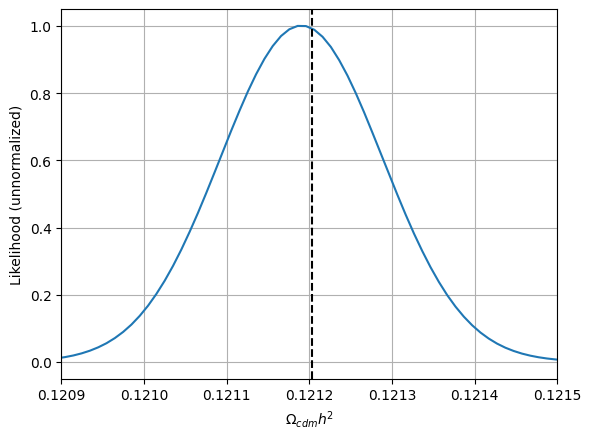

In [17]:
from tqdm import tqdm
like = EuclidLikelihood_GCspectro_Pls(data=data, settings=settings, Background=CAMBBackground, SpectroPower=CometEFT_SpectroPower)

omch2 = np.linspace(0.12, 0.1220, 200)
loglike_vals = []

for val in tqdm(omch2, desc="Computing likelihood"):
    # Update Omega_cdm0 parameter, making sure it's in the right form
    parameters['Omega_cdm0'] = val / (parameters['H0'] / 100.0)**2
    loglike_vals.append(like.loglike(parameters))

loglike_vals = np.array(loglike_vals)

# Convert log-likelihood to likelihood (unnormalized)
likelihood_vals = np.exp(loglike_vals - np.max(loglike_vals))  # subtract max for numerical stability

plt.plot(omch2, likelihood_vals)
plt.axvline(0.27 * 0.67**2, color='k', ls='--')
plt.xlim([0.1209, 0.1215])
plt.grid(True)
plt.xlabel(r'$\Omega_{cdm} h^2$')
plt.ylabel('Likelihood (unnormalized)')
plt.show()